<a href="https://colab.research.google.com/github/SahelKherad/3-story-benchmark-transformer/blob/main/t_SNE%20raw%20data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
from pathlib import Path

AMBIENT_DIR = Path("/content/drive/MyDrive/ASCE_IASC")

print("Folder exists:", AMBIENT_DIR.exists())
print("MAT files:")

mat_files = sorted(AMBIENT_DIR.glob("*.mat"))
for f in mat_files:
    print(f.name)

Folder exists: True
MAT files:
shm01a.mat
shm02a.mat
shm03a.mat
shm04a.mat
shm05a.mat
shm06a.mat
shm07a.mat
shm08a.mat
shm09a.mat


In [7]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from pathlib import Path

AMBIENT_DIR = Path("/content/drive/MyDrive/ASCE_IASC")

CHANNELS = [f"DA{i:02d}" for i in range(1, 16)]  # DA01 تا DA15


def load_ambient_mat(file_path, channels=CHANNELS):
    """
    Load one IASC-ASCE Ambient .mat file.

    Returns:
        X: shape = (samples, channels)
        fs: sampling frequency
        channel_names: list of channel names
    """
    mat = sio.loadmat(file_path, squeeze_me=True, struct_as_record=False)

    dasy = mat["dasy"]
    fs = float(mat["fsdasy"])

    signals = []

    for ch in channels:
        y = getattr(dasy, ch)
        y = np.asarray(y).squeeze()
        signals.append(y)

    X = np.column_stack(signals)

    return X, fs, channels

In [15]:
file_path = AMBIENT_DIR / "shm06a.mat"

X, fs, channel_names = load_ambient_mat(file_path)

print("File:", file_path.name)
print("Sampling frequency:", fs)
print("X shape:", X.shape)
print("Channels:", channel_names)

File: shm06a.mat
Sampling frequency: 200.0
X shape: (45568, 15)
Channels: ['DA01', 'DA02', 'DA03', 'DA04', 'DA05', 'DA06', 'DA07', 'DA08', 'DA09', 'DA10', 'DA11', 'DA12', 'DA13', 'DA14', 'DA15']


In [16]:
WINDOW_SIZE = 512
STRIDE = 512


def make_windows(X, window_size=WINDOW_SIZE, stride=STRIDE):
    windows = []

    n_samples = X.shape[0]

    for start in range(0, n_samples - window_size + 1, stride):
        end = start + window_size
        win = X[start:end, :]
        windows.append(win)

    return np.stack(windows)

In [17]:
make_windows(X).shape


(89, 512, 15)

In [19]:
def extract_window_features(windows):
    """
    windows shape: (num_windows, window_size, num_channels)

    returns:
        features shape: (num_windows, num_features)
    """

    mean_feat = np.mean(windows, axis=1)
    std_feat = np.std(windows, axis=1)
    rms_feat = np.sqrt(np.mean(windows ** 2, axis=1))
    max_feat = np.max(windows, axis=1)
    min_feat = np.min(windows, axis=1)
    ptp_feat = np.ptp(windows, axis=1)

    features = np.concatenate(
        [mean_feat, std_feat, rms_feat, max_feat, min_feat, ptp_feat],
        axis=1
    )

    return features

In [20]:
mat_files = sorted(AMBIENT_DIR.glob("shm*a.mat"))

all_features = []
all_labels = []
all_case_names = []

for file_path in mat_files:
    case_name = file_path.stem      # مثلا shm01a
    scenario_id = int(case_name[3:5])  # از shm01a عدد 01 را می‌گیرد

    X, fs, channel_names = load_ambient_mat(file_path)

    # حذف DC offset از هر سنسور
    X = X - np.mean(X, axis=0, keepdims=True)

    windows = make_windows(X)

    features = extract_window_features(windows)

    labels = np.full(features.shape[0], scenario_id)

    all_features.append(features)
    all_labels.append(labels)
    all_case_names.extend([case_name] * features.shape[0])

    print(case_name, "X:", X.shape, "windows:", windows.shape, "features:", features.shape)

X_feat = np.vstack(all_features)
y = np.concatenate(all_labels)

print("Final feature matrix:", X_feat.shape)
print("Final labels:", y.shape)
print("Unique scenarios:", np.unique(y))

shm01a X: (60000, 15) windows: (117, 512, 15) features: (117, 90)
shm02a X: (60000, 15) windows: (117, 512, 15) features: (117, 90)
shm03a X: (60000, 15) windows: (117, 512, 15) features: (117, 90)
shm04a X: (60000, 15) windows: (117, 512, 15) features: (117, 90)
shm05a X: (60000, 15) windows: (117, 512, 15) features: (117, 90)
shm06a X: (45568, 15) windows: (89, 512, 15) features: (89, 90)
shm07a X: (180000, 15) windows: (351, 512, 15) features: (351, 90)
shm08a X: (180000, 15) windows: (351, 512, 15) features: (351, 90)
shm09a X: (180000, 15) windows: (351, 512, 15) features: (351, 90)
Final feature matrix: (1727, 90)
Final labels: (1727,)
Unique scenarios: [1 2 3 4 5 6 7 8 9]


In [29]:
np.random.seed(42)

MAX_PER_SCENARIO = 360

selected_indices = []

for scenario_id in np.unique(y):
    idx = np.where(y == scenario_id)[0]

    if len(idx) > MAX_PER_SCENARIO:
        idx = np.random.choice(idx, size=MAX_PER_SCENARIO, replace=False)

    selected_indices.extend(idx)

selected_indices = np.array(selected_indices)

X_tsne_input = X_feat[selected_indices]
y_tsne = y[selected_indices]

print("Selected feature matrix:", X_tsne_input.shape)
print("Selected labels:", y_tsne.shape)

Selected feature matrix: (1727, 90)
Selected labels: (1727,)


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tsne_input)

In [31]:
from sklearn.decomposition import PCA

pca = PCA(n_components=30, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("PCA output shape:", X_pca.shape)
print("Explained variance ratio:", np.sum(pca.explained_variance_ratio_))

PCA output shape: (1727, 30)
Explained variance ratio: 0.9909340763782525


In [40]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_embedded = tsne.fit_transform(X_pca)

print("t-SNE shape:", X_embedded.shape)

t-SNE shape: (1727, 2)


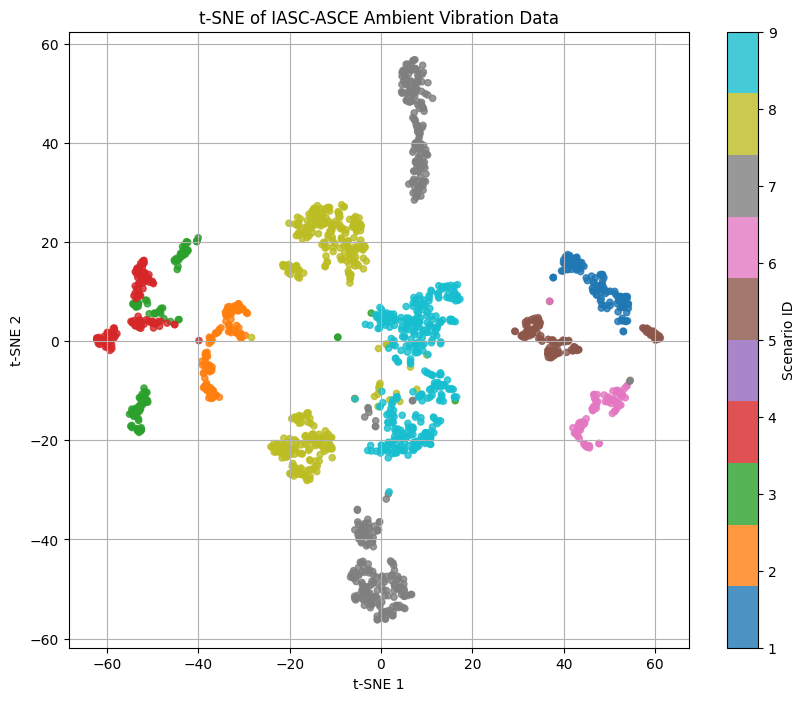

In [41]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_embedded[:, 0],
    X_embedded[:, 1],
    c=y_tsne,
    cmap="tab10",
    s=20,
    alpha=0.8
)

plt.colorbar(scatter, label="Scenario ID")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE of IASC-ASCE Ambient Vibration Data")
plt.grid(True)
plt.show()